In [92]:
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import seaborn as sns
from plotnine import *

In [93]:
electronic_sales = pd.read_excel("electromart_customer_sales.xlsx")
electronic_sales.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


### **DATA PREPARATION**

In [94]:
#convert Purchase Date into usable datetime to build Month, Quarter, and Season features.
electronic_sales["Purchase Date"] = pd.to_datetime(electronic_sales["Purchase Date"], errors="coerce")

In [95]:
#Month
electronic_sales["Month"] = electronic_sales["Purchase Date"].dt.month

#Quarter
electronic_sales["Quarter"] = electronic_sales["Purchase Date"].dt.quarter

#Season
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Fall"

electronic_sales["Season"] = electronic_sales["Month"].apply(get_season)

In [96]:
#Classified customers into high vs low spenders based on the median.
median_price =electronic_sales["Total Price"].median()
electronic_sales["HighValue"] = (electronic_sales["Total Price"] > median_price).astype(int)

I used the median instead of the mean because customer spending is highly skewed (as shown below in the EDA stage), with a few extremely high spenders pulling the average upward. The median provides a more stable and realistic threshold that splits customers into balanced groups, which improves machine learning model performance and produces more meaningful high-value customer labels.

In [97]:
electronic_sales['Gender'] = (
    electronic_sales['Gender']
    .map({'Male': 1, 'Female': 0})
    .fillna(1) # Fill NaN with 1 (mapped value for 'Male', which is the mode)
    .astype(int)
)

In [98]:
#Standardize Payment Method values (paypal) by cleaning text
electronic_sales["Payment Method"] = (
    electronic_sales["Payment Method"]
    .astype(str)
    .str.strip()                 # remove leading/trailing spaces
    .str.lower()                 # make consistent casing
    .replace({
        "PayPal": "paypal",
        "paypal ": "paypal"
    })
)

In [99]:
electronic_sales.head(20)


,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total,Month,Quarter,Season,HighValue
0,1000,53,1,No,Smartphone,SKU1004,2,Cancelled,credit card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21,3,1,Spring,1
1,1000,53,1,No,Tablet,SKU1002,3,Completed,paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09,4,2,Spring,0
2,1002,41,1,No,Laptop,SKU1005,3,Completed,credit card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00,10,4,Fall,0
3,1002,41,1,Yes,Smartphone,SKU1004,2,Completed,cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16,8,3,Summer,1
4,1003,75,1,Yes,Smartphone,SKU1001,5,Completed,cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56,5,2,Spring,0
5,1004,41,0,No,Smartphone,SKU1001,5,Completed,credit card,83.00,20.75,4,2024-05-26,Standard,"Impulse Item,Accessory",65.78,5,2,Spring,0
6,1005,25,0,No,Smartwatch,SKU1003,3,Completed,paypal,7603.47,844.83,9,2024-01-30,Overnight,NaN,0.00,1,1,Winter,1
7,1005,25,0,No,Laptop,SKU1005,3,Completed,debit card,4175.64,463.96,9,2024-06-24,Overnight,"Extended Warranty,Extended Warranty",75.33,6,2,Summer,1
8,1006,24,1,No,Smartphone,SKU1004,2,Cancelled,debit card,5538.33,791.19,7,2023-10-03,Standard,Impulse Item,43.05,10,4,Fall,1
9,1006,24,1,Yes,Laptop,SKU1005,3,Completed,cash,4175.64,463.96,9,2024-01-01,Express,NaN,0.00,1,1,Winter,1


### **EXPLORATORY DATA ANALYSIS**

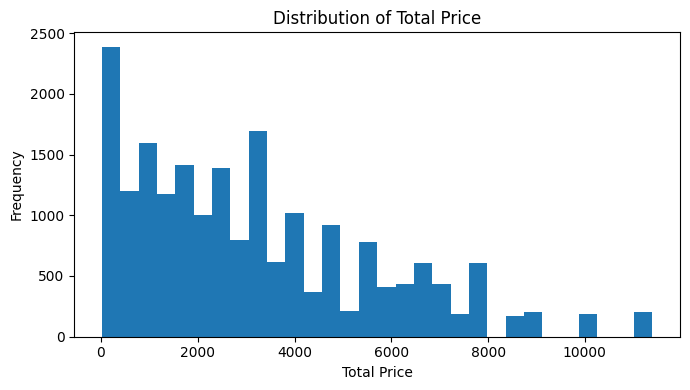

In [100]:
# 1. Total Price Distribution
plt.figure(figsize=(7,4))
plt.hist(electronic_sales["Total Price"], bins=30)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Total Price Distribution**

-Strong right-skew as seen above.

-Many low-mid purchases.

-Small number of very high spenders.

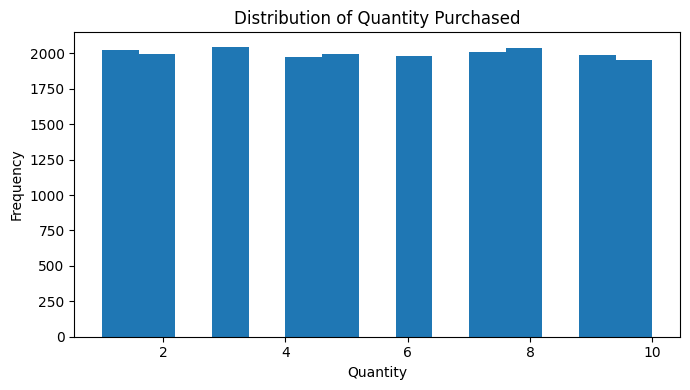

In [101]:
# 2. Quantity Distribution
plt.figure(figsize=(7,4))
plt.hist(electronic_sales["Quantity"], bins=15)
plt.title("Distribution of Quantity Purchased")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Quantity Distribution**

-Even spread from quantities 1–10.

-Suggests purchases often involve multiple items.

-Quantity may be a strong predictor in modeling.

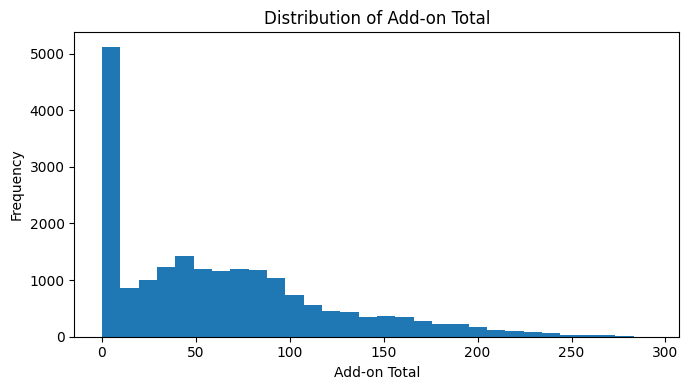

In [102]:
# 3. Add-on Total Distribution
plt.figure(figsize=(7,4))
plt.hist(electronic_sales["Add-on Total"], bins=30)
plt.title("Distribution of Add-on Total")
plt.xlabel("Add-on Total")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Add-on Total Distribution**

-Very right-skewed

-Majority buy no or low add-ons

-Small group buys expensive add-ons

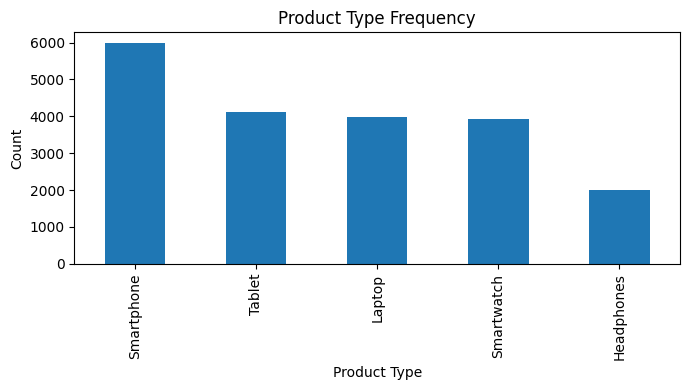

In [103]:
#Product Type Frequency
plt.figure(figsize=(7,4))
electronic_sales["Product Type"].value_counts().plot(kind="bar")
plt.title("Product Type Frequency")
plt.xlabel("Product Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Product Type Frequency**

-Smartphones dominate

-Followed by Tablets, Laptops, Smartwatches

-Headphones are the least purchased

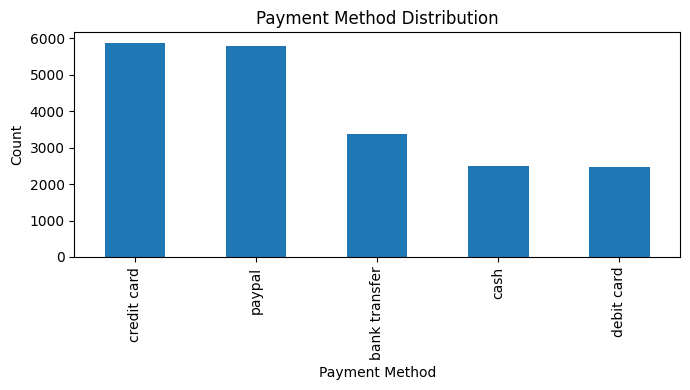

In [104]:
#Payment Method Frequency
plt.figure(figsize=(7,4))
electronic_sales["Payment Method"].value_counts().plot(kind="bar")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Payment Method Distribution**

-Strong dominance of Credit Card and Paypal

-Smaller use of Bank Transfer, Debit, Cash

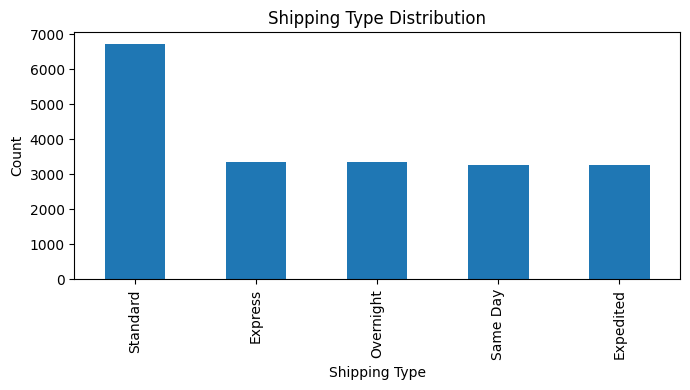

In [105]:
#Shipping Type Frequency
plt.figure(figsize=(7,4))
electronic_sales["Shipping Type"].value_counts().plot(kind="bar")
plt.title("Shipping Type Distribution")
plt.xlabel("Shipping Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Shipping Type Distribution**

-Standard > Express

-Customers value lower-cost shipping

-Shipping type may influence cancellations.

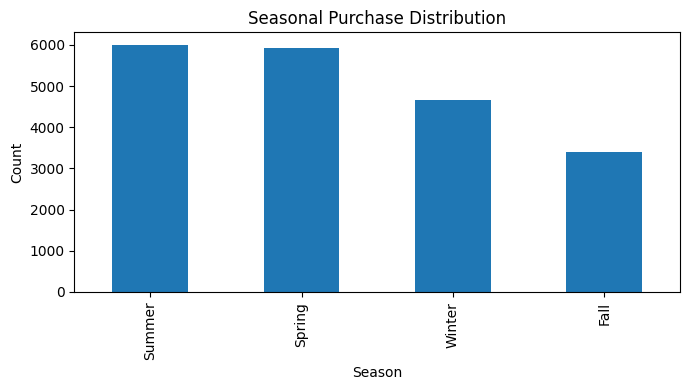

In [106]:
#Seasonal Spending Patterns
plt.figure(figsize=(7,4))
electronic_sales["Season"].value_counts().plot(kind="bar")
plt.title("Seasonal Purchase Distribution")
plt.xlabel("Season")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Seasonal Purchasing**

-Summer & Spring have most purchases.

-Fall has the lowest.

-Validates seasonal behavioral trends.

In [107]:
electronic_sales_heatmap = electronic_sales[
    ["Total Price", "Quantity", "Add-on Total", "Rating"]
]

corr = electronic_sales_heatmap.corr()

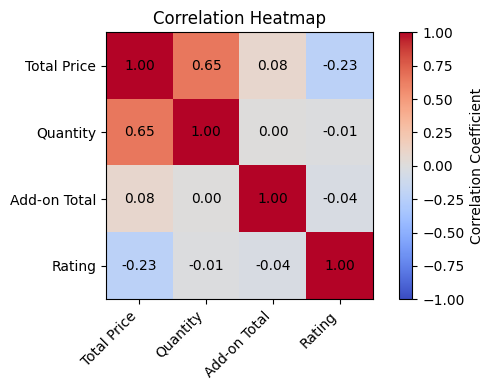

In [108]:
plt.figure(figsize=(6,4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation Coefficient")

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Correlation Heatmap**

-Quantity: strong positive correlation (0.65) with Total Price

-Add-on Total: weak linear relationship with Total Price

-Rating: weak to slightly negative relationship with spending



**EDA Summary:**

The EDA shows heavy right skew in total price and add on spending, with most customers making modest purchases and a small group spending significantly more. Quantity is evenly distributed across one to ten units, indicating frequent multi item orders. Product type frequency highlights strong concentration in smartphones, followed by tablets, laptops, and smartwatches. Credit card and Paypal payments dominate the dataset, and standard shipping is preferred over express. Seasonal patterns show higher purchasing in spring and summer with fall representing the lowest activity. Correlation (heatmap) analysis confirms that quantity is a  primary driver of total spending, while add on totals and customer ratings have weaker relationships.

Overall, the dataset presents clear purchasing patterns suitable for modeling and segmentation.

### **HYPOTHESIS TESTING (TWO SAMPLE T-TEST)**

**Tests whether customers who purchase add-ons spend more than those who don’t.**

In [109]:
df = electronic_sales

# Create binary variable: 1 = add-ons purchased, 0 = none
df["Addons_Purchased_Binary"] = df["Add-ons Purchased"].notna().astype(int)

# Split into two groups
addon_orders = df.loc[df["Addons_Purchased_Binary"] == 1, "Total Price"]
noaddon_orders = df.loc[df["Addons_Purchased_Binary"] == 0, "Total Price"]

# Two-sample t-test (equal_var=False because variances differ)
t_stat, p_value = stats.ttest_ind(addon_orders, noaddon_orders, equal_var=False)

print("Two-Sample T-Test: Total Price ~ Add-ons Purchased")
print("--------------------------------------------------")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print()
print("Mean Total Price (Add-ons Purchased):   ", addon_orders.mean())
print("Mean Total Price (No Add-ons Purchased):", noaddon_orders.mean())
print("Difference in Means:                    ", addon_orders.mean() - noaddon_orders.mean())

Two-Sample T-Test: Total Price ~ Add-ons Purchased
--------------------------------------------------
T-statistic: 0.4054
P-value: 0.685181

Mean Total Price (Add-ons Purchased):    3184.2618497224425
Mean Total Price (No Add-ons Purchased): 3167.3003410024653
Difference in Means:                     16.961508719977246


**Result:**

t = 0.405, p = 0.685 (NOT significant)

There is no significant difference in total spending between customers who purchased add-ons and those who did not.
This means that simply buying an add-on does not indicate higher spending.
Behavioral value is therefore not driven by add-on participation alone, but by what and how much customers purchase overall. Add-ons are, therefore, not a strong or useful measure for explaining variation in total price.

**REGRESSION MODEL:**

**Does spending differ between product categories?**

In [110]:
model_product = smf.ols(
    'Q("Total Price") ~ C(Q("Product Type"))',
    data=electronic_sales
).fit()

print("REGRESSION: Product Type Predicting Total Price")
print("------------------------------------------------")
print(model_product.summary(), "\n")

REGRESSION: Product Type Predicting Total Price
------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:       Q("Total Price")   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     195.0
Date:                Thu, 15 Jan 2026   Prob (F-statistic):          2.67e-164
Time:                        22:57:19   Log-Likelihood:            -1.8483e+05
No. Observations:               20000   AIC:                         3.697e+05
Df Residuals:                   19995   BIC:                         3.697e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
----------

All product type coefficients are highly significant (p < 0.001). Product category has a statistically significant effect on spending.
Compared to the baseline product (Headphones), customers spend significantly more on: Laptops, Smartphones, Smartwatches, and Tablets

This confirms that product choice is a meaningful behavioral driver of customer spending, even though spending varies widely.

**Do certain products sell better in certain seasons?**

In [111]:
interaction_model = smf.ols(
    'Q("Total Price") ~ C(Q("Product Type")) * C(Season)',
    data=electronic_sales
).fit()

print("INTERACTION MODEL: Product Type × Season Predicting Total Price")
print("-----------------------------------------------------------------")
print(interaction_model.summary())

INTERACTION MODEL: Product Type × Season Predicting Total Price
-----------------------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:       Q("Total Price")   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     58.57
Date:                Thu, 15 Jan 2026   Prob (F-statistic):          8.19e-218
Time:                        22:57:19   Log-Likelihood:            -1.8467e+05
No. Observations:               20000   AIC:                         3.694e+05
Df Residuals:                   19980   BIC:                         3.695e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err    

The overall interaction model is highly significant (p ≈ 8.19e-218). The effect of product category on spending depends on the season.
Certain products generate noticeably higher spending in specific seasons:

*   Smartphones and Smartwatches show increased spending in Spring and Summer.
*   Tablets spike in Summer.

Some categories show significantly lower spending in certain seasons (e.g., Smartwatch × Winter). Coefficient is -772.40.

This indicates seasonal buying behavior: customers prefer different electronic products at different times of the year.

**Does Payment Method affect Total Price?**

In [112]:
model_payment = smf.ols(
    formula='Q("Total Price") ~ C(Q("Payment Method"))',
    data=df
).fit()

print(model_payment.summary())

print("Model p-value:", model_payment.f_pvalue)

                            OLS Regression Results                            
Dep. Variable:       Q("Total Price")   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     112.6
Date:                Thu, 15 Jan 2026   Prob (F-statistic):           4.30e-95
Time:                        22:57:20   Log-Likelihood:            -1.8499e+05
No. Observations:               20000   AIC:                         3.700e+05
Df Residuals:                   19995   BIC:                         3.700e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

The regression results show that payment method has a statistically significant relationship with total price, although the overall explanatory power is modest with an R² of 2.2%. Several payment methods are associated with noticeably lower spending compared to the baseline group (bank transfer). Cash, debit card, and Credit card categories all show large negative coefficients, indicating that customers using these methods tend to place lower value orders. Paypal users also spend less than the baseline, but the drop is smaller.

Overall, payment method appears to influence spending patterns, with certain methods consistently linked to lower total prices.

### **PREDICTIVE MODELING (SUPERVISED MACHINE LEARNING)**

In [113]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

**A. Feature Engineering. Determining our target and feature variables**

In [114]:
pred_elec = electronic_sales

pred_elec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Customer ID              20000 non-null  int64         
 1   Age                      20000 non-null  int64         
 2   Gender                   20000 non-null  int64         
 3   Loyalty Member           20000 non-null  object        
 4   Product Type             20000 non-null  object        
 5   SKU                      20000 non-null  object        
 6   Rating                   20000 non-null  int64         
 7   Order Status             20000 non-null  object        
 8   Payment Method           20000 non-null  object        
 9   Total Price              20000 non-null  float64       
 10  Unit Price               20000 non-null  float64       
 11  Quantity                 20000 non-null  int64         
 12  Purchase Date            20000 n

In [115]:
target = pred_elec.loc[:,'Total Price']

In [116]:
predictors = pred_elec.loc[:,["Product Type","Shipping Type","Payment Method","Season",
    "Quantity","Add-on Total","Rating"]]

**Feature Selection**

In [117]:
encoder = OneHotEncoder(sparse_output = True)

In [118]:
num_feats = ["Quantity","Add-on Total","Rating"]
cat_feats = ["Product Type","Shipping Type","Payment Method","Season"]

In [119]:
final_pipe = ColumnTransformer([
   ('num', StandardScaler(), num_feats),
   ('cat', encoder, cat_feats)
])

In [120]:
features_processed = final_pipe.fit_transform(predictors)

**B. Spliting the data into training and testing**

In [121]:
from sklearn.model_selection import train_test_split

In [122]:
feat_train, feat_test, tgt_train, tgt_test = train_test_split(features_processed,
                                      target, test_size = 0.25, random_state = 42)

In [123]:
print(pred_elec.shape)


(20000, 21)


In [124]:
print("Dimension for training features: ", feat_train.shape)

Dimension for training features:  (15000, 22)


In [125]:
print("Dimension for testing features: ", feat_test.shape)

Dimension for testing features:  (5000, 22)


**C. Build a Model**

**(i) Linear Regression Model:**

In [126]:
from sklearn.linear_model import LinearRegression

In [127]:
linear_model = LinearRegression()
linear_model.fit(feat_train, tgt_train)

LinearRegression()

In [128]:
predicted_totalprice = linear_model.predict(feat_test)

**Model Assessment: predict on Test set, compare results.**

In [129]:
(
    pd.DataFrame({
        'actual_totalprice' : list(tgt_test),
        'predicted_totalprice' : list(predicted_totalprice)
    })
).head(n = 10)

,actual_totalprice,predicted_totalprice
0,5394.56,4691.457122
1,1976.24,3963.524436
2,2534.49,1606.761289
3,5538.33,4211.131891
4,4045.92,3102.735126
5,4045.92,3112.607833
6,1378.50,1728.827431
7,145.25,2887.638814
8,1444.72,1853.914089
9,2223.27,4930.807590


**Evaluating Model Performance:**

In [130]:
from sklearn.metrics import mean_squared_error

In [131]:
mse = mean_squared_error(tgt_test, predicted_totalprice)
print("The test MSE from a Linear Regression model is ", mse)

The test MSE from a Linear Regression model is  2715672.8265586784


In [132]:
predicted_totalprice = linear_model.predict(feat_train)
mse = mean_squared_error(tgt_train, predicted_totalprice)
print("The training MSE from a Linear Regression model is ", mse)

The training MSE from a Linear Regression model is  2652908.8028360815


The Linear Regression model achieves a training MSE of 2.65M and a test MSE of 2.71M. The difference between training and test error indicates reasonable generalization with minimal overfitting. Although the MSE values appear large, this is primarily because MSE uses squared errors. Some prediction errors are in the range of 1,000-2,000, and squaring these values naturally leads to error terms in the millions. Overall, the model captures basic spending patterns but cannot fully model the nonlinear relationships found in customer behavior.

**Regularization models:** Deals with the model's complexity to prevent overfitting

In [133]:
from sklearn.linear_model import Lasso

In [134]:
lasso_model = Lasso(alpha = 0.1, max_iter = 100000)
lasso_model.fit(feat_train, tgt_train)

Lasso(alpha=0.1, max_iter=100000)

In [135]:
predicted_totalprice = lasso_model.predict(feat_test)
mse = mean_squared_error(tgt_test, predicted_totalprice)
print("The MSE from Lasso model is ", mse)

The MSE from Lasso model is  2715699.5779902735


In [136]:
coefficients = np.array(lasso_model.coef_)
print(coefficients)

[ 1659.74727696    82.28164895  -581.13237034 -1757.73994778
    -0.           815.98939251   411.03414379  -274.75104243
   618.39540882  -628.66063481  -526.00662202   623.71439023
     0.           284.19415473  -407.69609344    19.69877351
  -308.14346425    -0.           -92.28723564    18.79401721
    56.1289966    -50.71116656]


In [137]:
zero_threshold = 1e-3
print(np.abs(coefficients) < zero_threshold)

[False False False False  True False False False False False False False
  True False False False False  True False False False False]


LASSO model produced a similar MSE to the Test linear model (2.71M), indicating that regularization did not meaningfully improve prediction accuracy. This suggests that all behavioral features provide predictive value (as showed above with only three variables showing True), and the spending behavior is better captured by nonlinear models such as decision trees and SVMs.

In [138]:
from sklearn.model_selection import cross_val_score, KFold

In [139]:
alpha_values = [0.1, 1, 5, 10]

In [140]:
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

In [141]:
tgt_scaler = StandardScaler()
tgt_train_scaled = tgt_scaler.fit_transform(tgt_train.values.reshape(-1,1)).ravel()

In [142]:
alpha_mse = []

for alpha in alpha_values:
    model = Lasso(alpha=alpha, max_iter=100000)
    mse_scores = cross_val_score(
        model,
        feat_train,
        tgt_train,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
    mean_mse = -np.mean(mse_scores)
    alpha_mse.append(mean_mse)

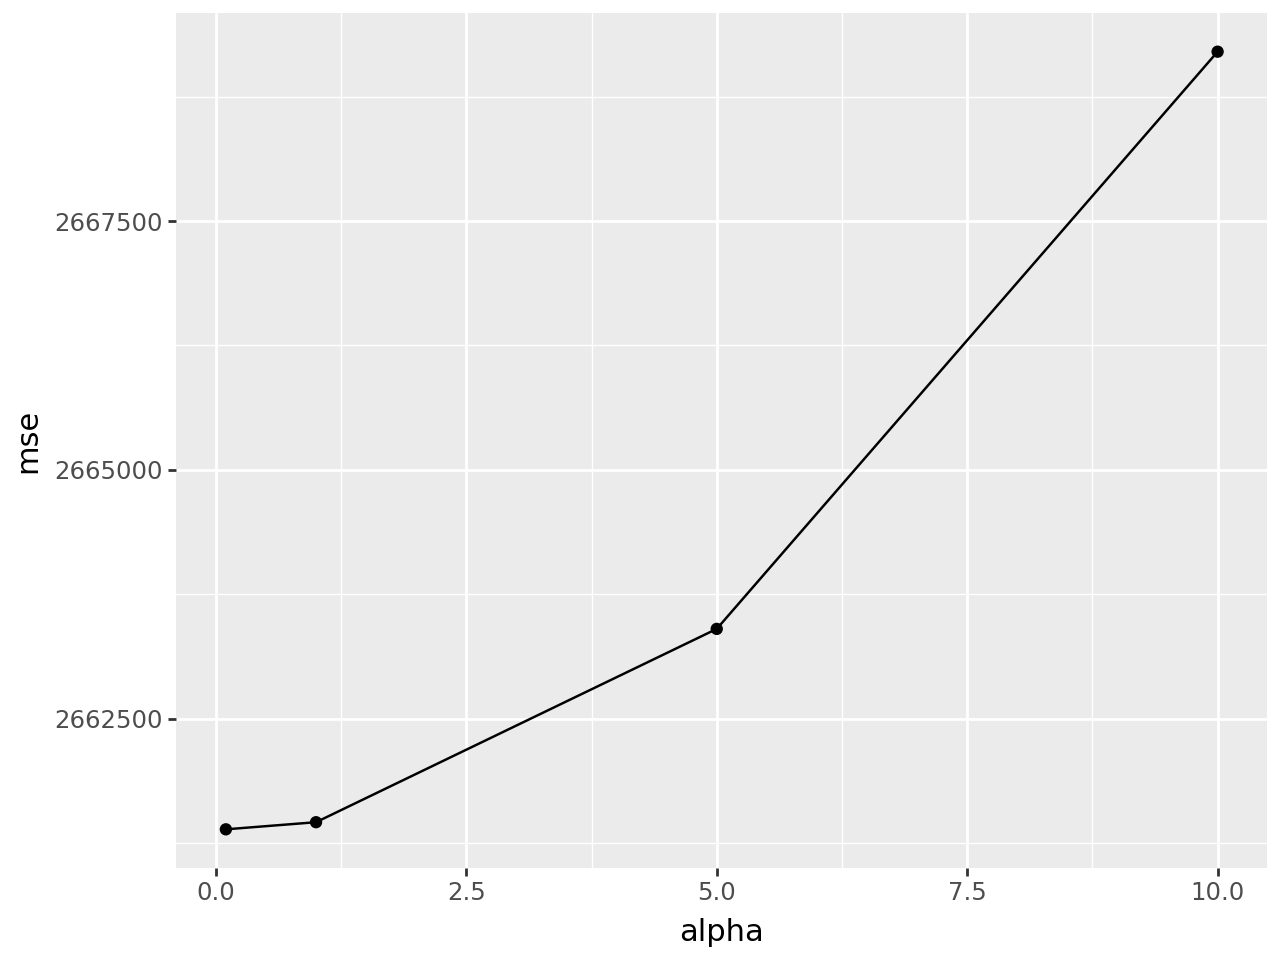

In [143]:
from plotnine import (
    ggplot,
    aes,
    geom_line,
    geom_point,
    labs
)

plot_data = pd.DataFrame({"alpha" : alpha_values, "mse" : alpha_mse})

(
    ggplot(plot_data, aes(x = "alpha", y = "mse")) +
        geom_line() +
        geom_point()
)

I believe the best value is the one with the lowest MSE so around 0.001 from the above graph.

In [144]:
tuned_model = Lasso(alpha = 0.001)
tuned_model.fit(feat_train, tgt_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.367e+09, tolerance: 9.728e+06


Lasso(alpha=0.001)

In [145]:
predicted_totalprice = tuned_model.predict(feat_test)
mse = mean_squared_error(tgt_test, predicted_totalprice)
print("The MSE from the tuned Lasso model is ", mse)

The MSE from the tuned Lasso model is  2715673.1142000672


Tuned Lasso Model also did not significantly improve the model's performance.

In [146]:
rmse = np.sqrt(mean_squared_error(tgt_test,  predicted_totalprice))
rmse

np.float64(1647.929948207771)

**Conclusion from Linear Regression Model:**

The Linear Regression model achieved an RMSE of 1,647.93, meaning its predictions deviate from actual spending by about $1,648 on average. Given the wide range of transaction amounts in the dataset, this level of error is reasonable. The results show that behavioral features (product type, quantity, add-on total, shipping type, payment method, rating, and season) contribute meaningfully to predicting customer spending. This confirms that behavioral factors influence customer value and supports the broader research objective of understanding behaviorial factors that drive high-value purchases.

**(ii) Logistic Regression (Classification: High-Value vs Low-Value):**

In [147]:
y = electronic_sales.loc[:,["HighValue"]]

In [148]:
predictors = electronic_sales.loc[:,["Product Type","Shipping Type","Payment Method","Season",
    "Quantity","Add-on Total","Rating"]]

In [149]:
x_train, x_test, y_train, y_test = train_test_split(features_processed,
    y, test_size=0.25, random_state=42)

In [150]:
from sklearn.linear_model import LogisticRegression

In [151]:
logis_model = LogisticRegression()
logis_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().


LogisticRegression()

In [152]:
logis_predict = logis_model.predict(x_test)

In [153]:
(
    pd.DataFrame({
        'actual_highvalue' : list(y_test.values.flatten()),
        'predicted_highvalue' : list(logis_predict)
    })
).head(n = 10)

,actual_highvalue,predicted_highvalue
0,1,1
1,0,1
2,0,0
3,1,1
4,1,1
5,1,1
6,0,0
7,0,0
8,0,0
9,0,1


**Evaluating Model Performance:**

In [154]:
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix

In [155]:
log_acc = accuracy_score(y_test, logis_predict)
log_acc

0.8174

In [156]:
log_cm = confusion_matrix(y_test, logis_predict)
pd.DataFrame(log_cm,
             columns = ["Predicted lowvalue", "Predicted highvalue"],
             index = ["Actual lowvalue", "Actual highvalue"])

,Predicted lowvalue,Predicted highvalue
Actual lowvalue,2095,475
Actual highvalue,438,1992


**Conclusion from Logistic Regression Model:**

The Logistic Regression model achieved an accuracy of **81.74%**, demonstrating that behavioral variables alone provide strong predictive ability in distinguishing high-value from low-value customers. The model correctly classified the majority of customer transactions and showed balanced performance across both classes. These findings confirm that behavioral patterns, such as product choice, order quantity, add-on spending, payment method, shipping preference, and seasonal timing, are meaningful indicators of customer value. This strengthens the study’s conclusion that behavioral factors predict high-value customers more effectively than demographic variables or loyalty membership.

The confusion matrix shows that the logistic regression model performs well at identifying both high-value and low-value customers. It correctly classified 2095 low-value customers and 1992 high-value customers. Misclassifications were relatively balanced, with 475 false positives and 438 false negatives. This indicates that the model does not overly favor one class and is capable of distinguishing customer value categories with reasonable accuracy.

**(iii) Decision Tree Classifier (Non-linear ML):**

In [157]:
from sklearn.tree import DecisionTreeClassifier

In [158]:
decision_model = DecisionTreeClassifier(random_state = 42,
                               max_depth = 4,
                               min_samples_leaf = 20,
                               min_samples_split = 50)
decision_model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, min_samples_split=50,
                       random_state=42)

In [159]:
import matplotlib.pyplot as plt

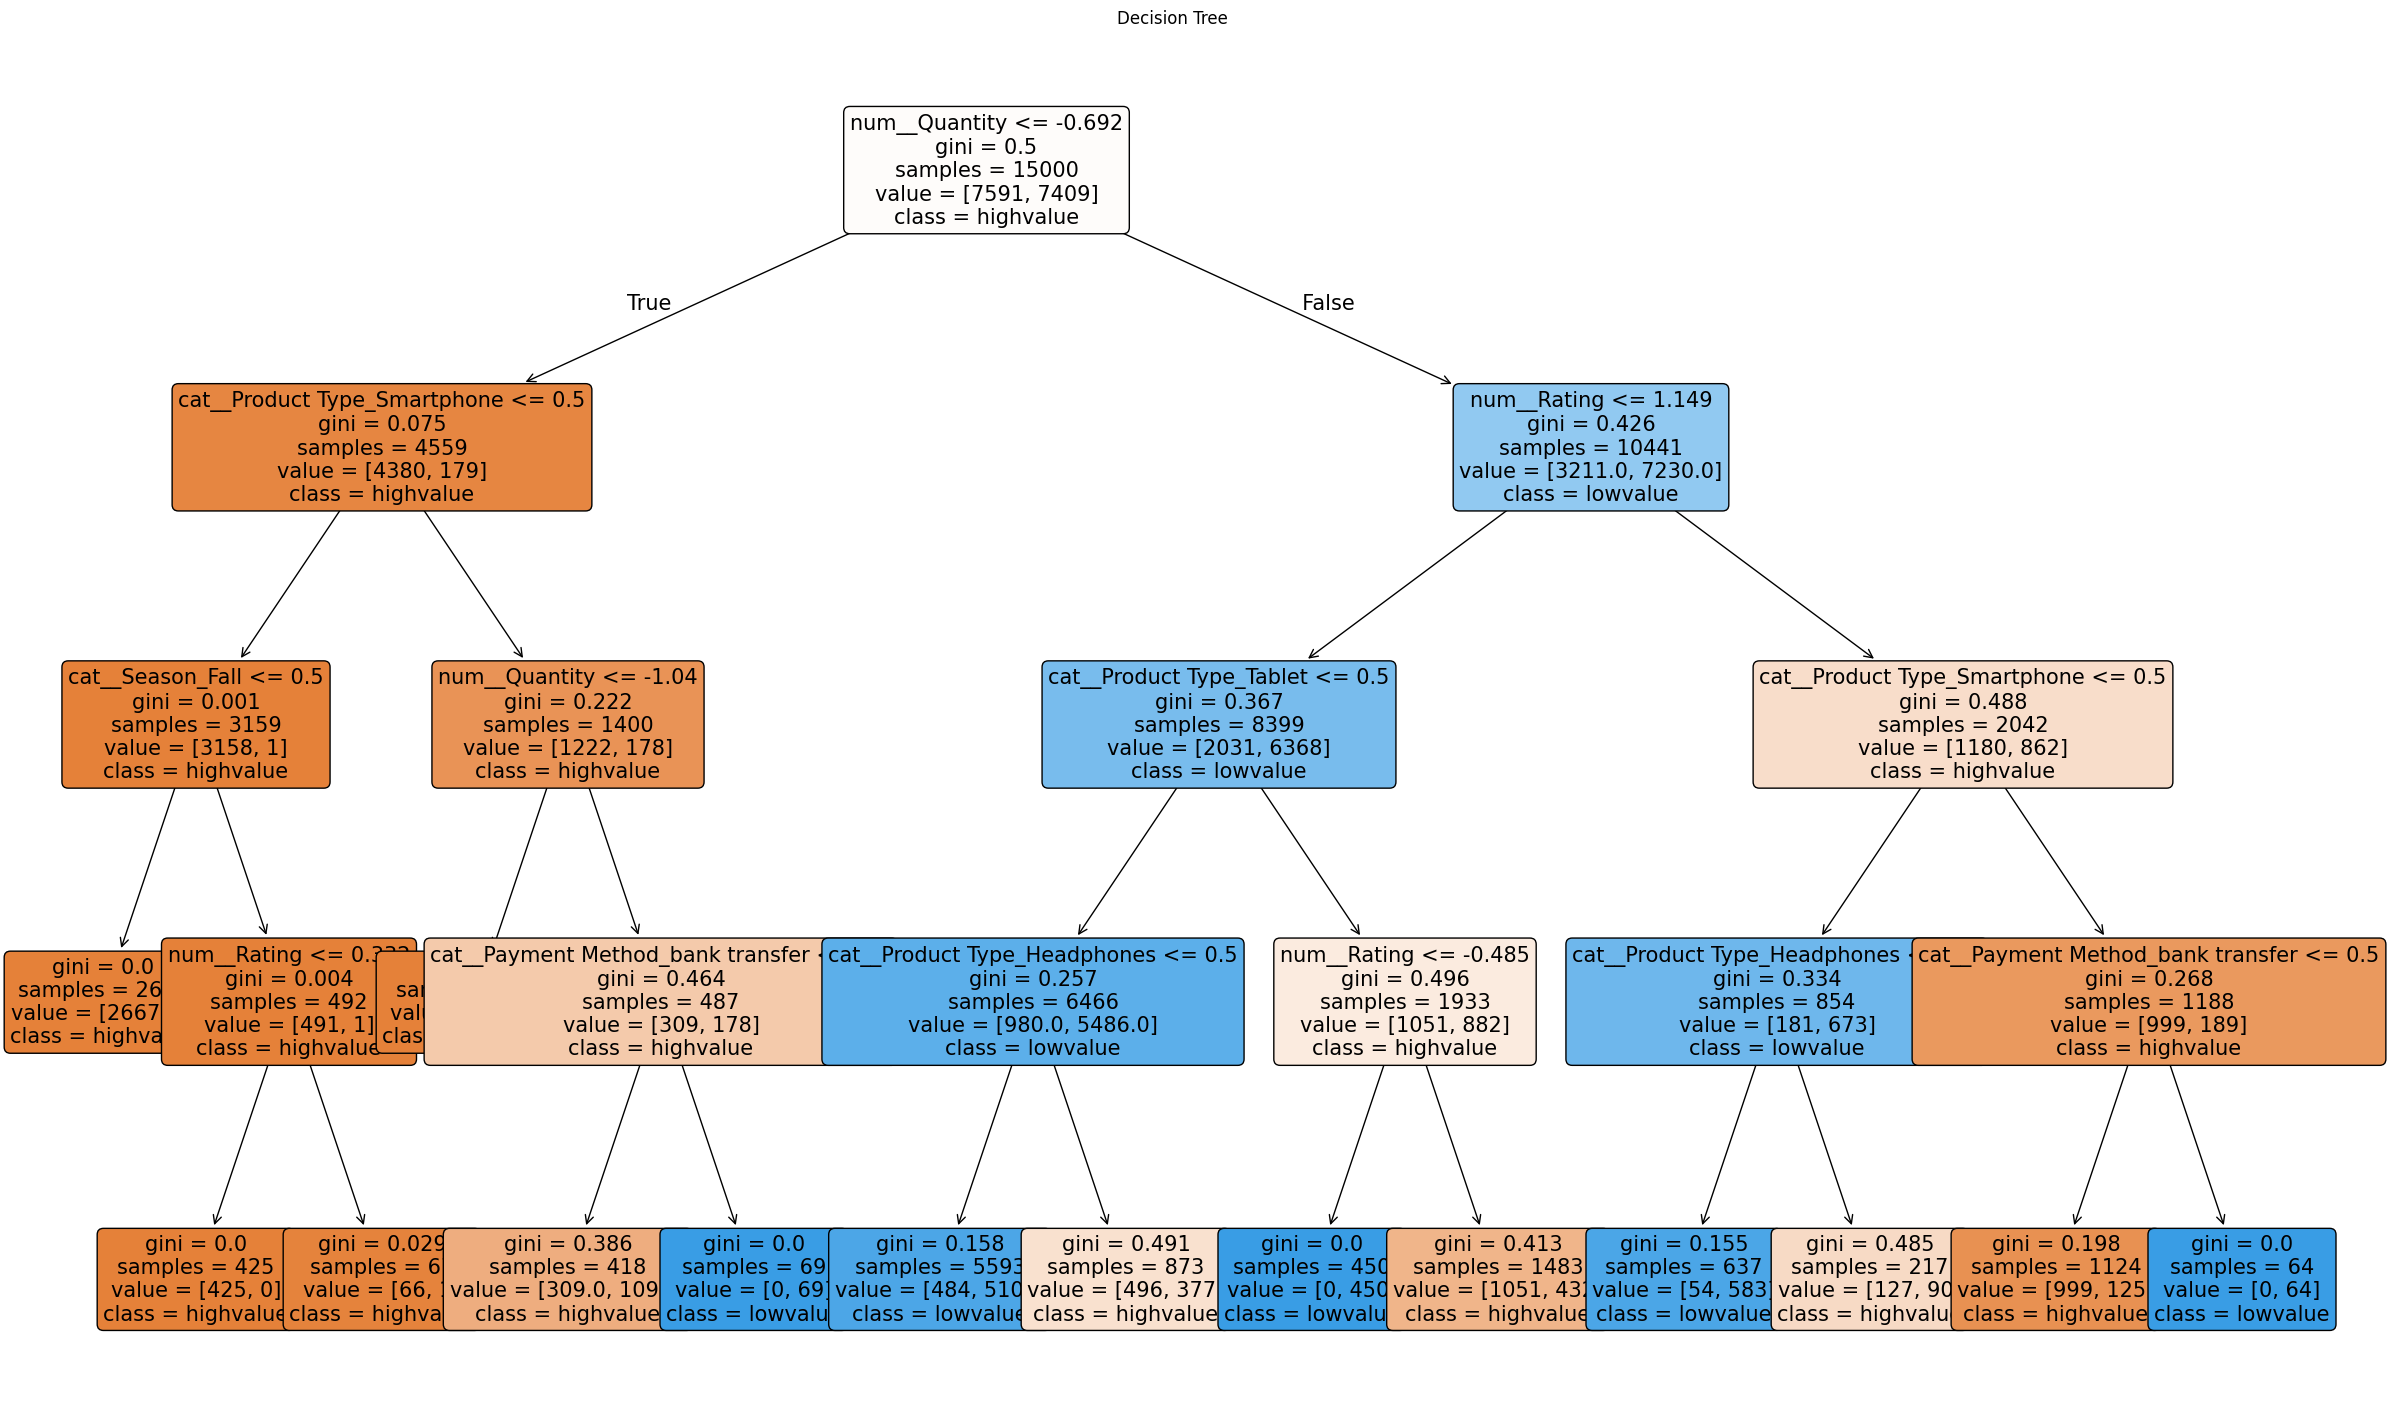

In [160]:
from sklearn.tree import plot_tree

# Get feature names after preprocessing
predictor_names_transformed = final_pipe.get_feature_names_out()

plt.figure(figsize = (30, 18))
plot_tree(
    decision_model,
    feature_names = predictor_names_transformed,
    class_names = ["highvalue", "lowvalue"],
    filled = True,
    rounded = True,
    fontsize = 15
)
plt.title("Decision Tree")
plt.show()

In [161]:
tree_predict = decision_model.predict(x_test)

In [162]:
tree_acc = accuracy_score(y_test, tree_predict)
tree_acc

0.8788

In [163]:
tree_cm = confusion_matrix(y_test, tree_predict)
pd.DataFrame(tree_cm,
             columns = ["Predicted lowvalue", "Predicted highvalue"],
             index = ["Actual lowvalue", "Actual highvalue"])

,Predicted lowvalue,Predicted highvalue
Actual lowvalue,2348,222
Actual highvalue,384,2046


**Conclusion from Decision Tree Classifier:**

The Decision Tree classifier achieved a strong accuracy of 87.88%, indicating robust performance in predicting customer value. The confusion matrix results show that the model correctly classified 2348 low-value customers and 2046 high-value customers, with relatively few misclassifications (222 false positives and 384 false negatives). These results confirm that the model effectively captures the behavioral patterns that distinguish high-value from low-value customers.

The decision tree model classifies customers into high-value and low-value segments by first splitting on purchase quantity, indicating that quantity is the strongest predictor of customer value. Customers with lower purchase quantities are overwhelmingly classified as high value with high model confidence, while customers with higher quantities require further segmentation. For these customers, product type and customer ratings become critical: purchases involving smartphones and tablets are more strongly associated with high-value customers, whereas headphones are more often linked to low-value outcomes, particularly when customer ratings are lower. Customer ratings act as an important quality signal, with higher ratings shifting customers toward the high-value segment and lower ratings increasing the likelihood of low-value classification. Seasonality and payment method appear as secondary factors that refine predictions within already defined groups rather than driving value on their own. Overall, the tree shows that customer value is determined by an interaction of purchasing behavior, product choice, and customer satisfaction, producing clear and interpretable rules that explain why certain customers are consistently high value while others are not.

**Model Comparison Summary: Logistic Regression vs. Decision Tree**

Between the two supervised learning models tested, the Decision Tree outperformed Logistic Regression in both predictive accuracy and interpretability. The Decision Tree achieved an accuracy of 87.88%, compared to 81.84% for Logistic Regression, and produced fewer misclassification errors across both high-value and low-value customer groups. More importantly, the Decision Tree revealed non-linear behavioral patterns and meaningful segmentation rules that logistic regression could not capture. These insights align more closely with ElectroMart’s strategic need for actionable, behavior-driven customer segmentation. Therefore, the Decision Tree is the superior model for predicting customer value and guiding targeted marketing interventions.

**CLUSTERING ANALYSIS (UNSUPERVISED MACHINE LEARNING)**

In [164]:
from sklearn.cluster import KMeans

In [165]:
req_cols = [ "Product Type", "Shipping Type", "Payment Method", "Season",
             "Quantity", "Add-on Total", "Rating"]
clustering_features = electronic_sales.loc[:,req_cols]

In [166]:
categorical_cols = ["Product Type", "Shipping Type", "Payment Method", "Season"]
numeric_cols = ["Quantity", "Add-on Total", "Rating"]

In [167]:
cluster_preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

In [168]:
scaled_features = cluster_preprocess.fit_transform(clustering_features)
print(scaled_features)

[[ 0.          0.          1.         ...  0.52753913 -0.37953831
  -0.89394472]
 [ 0.          0.          0.         ... -0.86580929 -0.62274766
  -0.07677326]
 [ 0.          1.          0.         ... -0.51747218 -1.07213377
  -0.07677326]
 ...
 [ 1.          0.          0.         ... -0.16913508  2.35518888
   0.7403982 ]
 [ 1.          0.          0.         ...  0.52753913  0.6733928
  -1.71111618]
 [ 0.          1.          0.         ... -1.56248349 -1.07213377
   0.7403982 ]]


In [169]:
#Elbow Method: uses within sum of squares
def wss_calculation(K, data):
    WSS = []
    for i in range(K):
        cluster = KMeans(n_clusters = i + 1, random_state = 1)
        cluster.fit_predict(data)
        label = cluster.labels_
        wss = []
        for j in range(i+1):
            idx = [t for t, e in enumerate(label) if e == j]
            cluster = data[idx,]
            cluster_mean = cluster.mean(axis = 0)
            distance = np.sum(np.abs(cluster - cluster_mean)**2,
                                                  axis = -1)
            wss.append(sum(distance))
        WSS.append(sum(wss))
    return WSS

In [170]:
WSS = wss_calculation(10, scaled_features)

In [171]:
plot_data = pd.DataFrame({"clusters": range(1,11),
                          "WSS": WSS})

print(plot_data)

   clusters            WSS
0         1  121325.165600
1         2  106959.177394
2         3   95097.293660
3         4   86706.193925
4         5   83765.856254
5         6   80418.907046
6         7   77618.248687
7         8   75586.786962
8         9   75050.208964
9        10   73493.144016


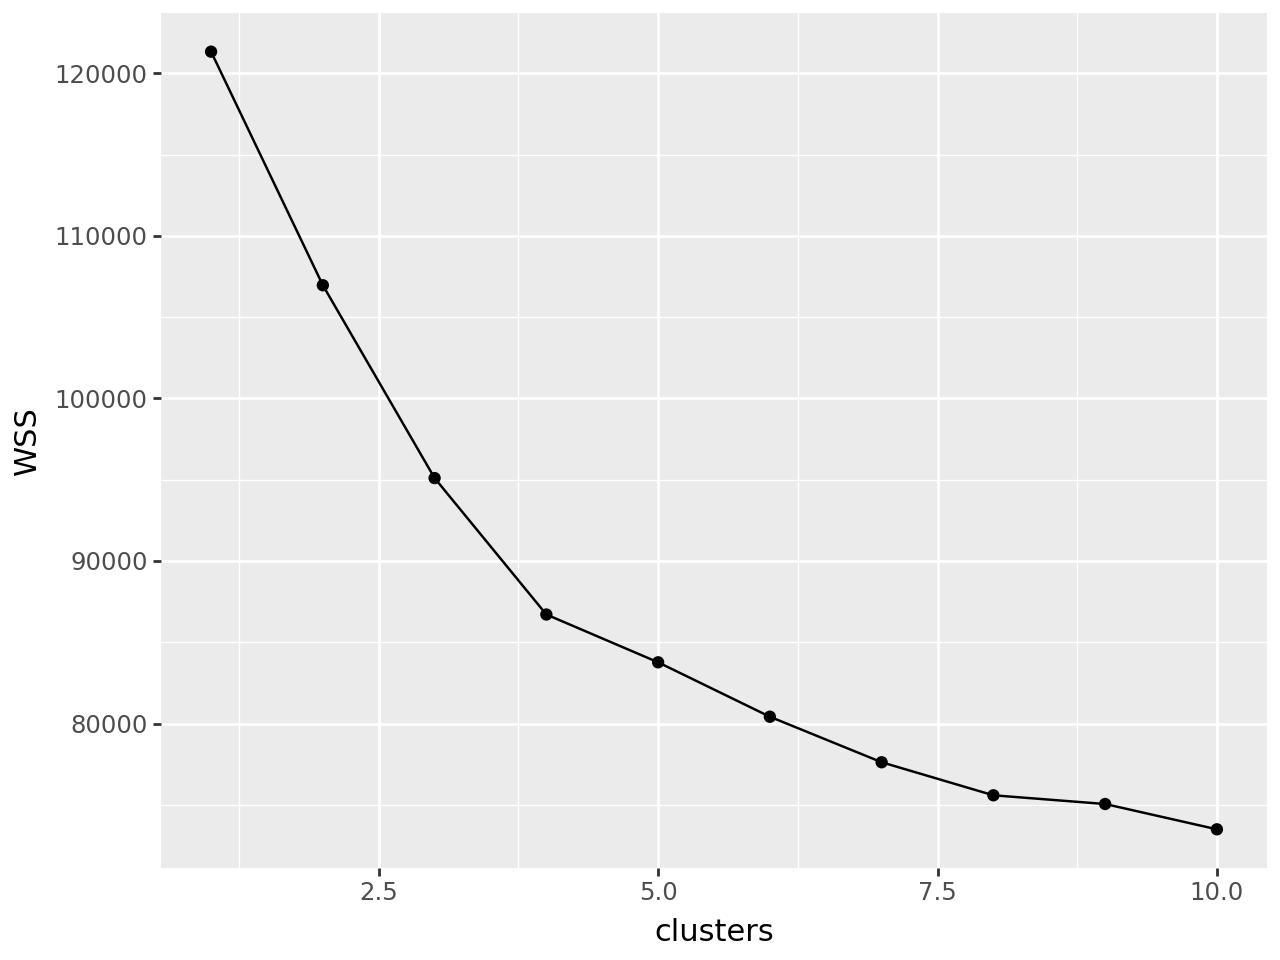

In [172]:
(
    ggplot(plot_data, aes(x = "clusters", y = "WSS"))
        + geom_point()
        + geom_line()
)

I used **k = 4** as the optimal number of clusters, as there are diminishing improvements beyond this point.

In [173]:
kmeans_model = KMeans(n_clusters = 4, random_state = 1)
segment_kmeans = kmeans_model.fit(scaled_features)

In [174]:
electronic_sales['segment'] = segment_kmeans.labels_
electronic_sales.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,...,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total,Month,Quarter,Season,HighValue,Addons_Purchased_Binary,segment
0,1000,53,1,No,Smartphone,SKU1004,2,Cancelled,credit card,5538.33,...,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21,3,1,Spring,1,1,3
1,1000,53,1,No,Tablet,SKU1002,3,Completed,paypal,741.09,...,2024-04-20,Overnight,Impulse Item,26.09,4,2,Spring,0,1,2
2,1002,41,1,No,Laptop,SKU1005,3,Completed,credit card,1855.84,...,2023-10-17,Express,NaN,0.00,10,4,Fall,0,0,2
3,1002,41,1,Yes,Smartphone,SKU1004,2,Completed,cash,3164.76,...,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16,8,3,Summer,1,1,2
4,1003,75,1,Yes,Smartphone,SKU1001,5,Completed,cash,41.50,...,2024-05-21,Express,Accessory,35.56,5,2,Spring,0,1,0


In [175]:
cluster_summary = electronic_sales.groupby("segment")[[
    "Quantity", "Add-on Total", "Rating", "Total Price"
]].mean()

cluster_summary

,Quantity,Add-on Total,Rating,Total Price
segment,,,,
0,5.395402,47.430414,4.823908,2158.838232
1,5.596136,161.825666,2.795352,3748.638605
2,2.867738,41.363612,2.554690,1771.407881
3,8.102024,40.091279,2.573603,5000.334737


In [176]:
pd.crosstab(electronic_sales["segment"], electronic_sales["Product Type"], normalize="index")

Product Type,Headphones,Laptop,Smartphone,Smartwatch,Tablet
segment,,,,,
0,0.106667,0.094943,0.585517,0.100000,0.112874
1,0.201026,0.205856,0.195291,0.191669,0.206158
2,0.071730,0.238072,0.221194,0.232554,0.236449
3,0.071093,0.228502,0.230121,0.231741,0.238543


**Segment 0: Loyal Core Smartphone Buyers**

-Moderate quantity (~5.4 items/order)

-Low add-on spend (~$47)

-Very high ratings (~4.8)

-Moderate total spend (~$2,159)

-Strong smartphone concentration (~59%)

**Interpretation:**
These customers buy primarily smartphones, purchase at a steady but controlled volume, and report very high satisfaction. They are not heavy add-on buyers, but their consistent behavior and strong experience signal make them reliable, long-term customers.

**Segment 1: Add-On Revenue Drivers**

-Moderate quantity (~5.6 items/order)

-Highest add-on spend (~$162)

-Low ratings (~2.8)

-High total spend (~$3,749)

-Balanced product mix (no dominant category)

**Interpretation:**
This segment generates revenue primarily through add-ons, not volume. Despite high spending, customer satisfaction is relatively low, suggesting friction in the buying or post-purchase experience. Revenue is strong, but loyalty is fragile.

**Segment 2: Low-Engagement Occasional Buyers**

-Lowest quantity (~2.9 items/order)

-Low add-on spend (~$41)

-Low ratings (~2.6)

-Lowest total spend (~$1,771)

-Evenly spread product mix

**Interpretation:**
These customers show minimal engagement across all dimensions: low spending, low satisfaction, and no clear product preference. They appear to be infrequent or trial buyers with limited attachment to the brand.

**Segment 3: High-Volume Transactional Buyers**

-Highest quantity (~8.1 items/order)

-Low add-on spend (~$40)

-Low ratings (~2.6)

-Highest total spend (~$5,000)

-Broad product mix (tablets, laptops, smartphones, smartwatches)

**Interpretation:**
This group generates very high revenue through volume, but reports low satisfaction. They appear to be transactional buyers, possibly price-driven or bulk purchasers, who deliver revenue but limited long-term value without intervention.

In [177]:
pd.crosstab(electronic_sales["segment"], electronic_sales["HighValue"], normalize="index") * 100

HighValue,0,1
segment,,
0,65.609195,34.390805
1,37.669786,62.330214
2,79.503408,20.496592
3,18.785425,81.214575


**Interpretation:**

Comparing the behavioral customer segments to the HighValue classification shows a clear and intuitive alignment between how customers behave and the value they generate for the business. **Segment 3** stands out as the strongest high-value segment, with over 80% of customers classified as high value, driven by their high purchase volumes and overall spending. **Segment 1** also skews toward high-value customers, with roughly 62% classified as high value, reflecting strong revenue contribution primarily through add-on purchases, though this group may require experience improvements to sustain long-term value. In contrast, **Segments 0 and 2** are predominantly low-value, with the majority of customers in these segments contributing lower revenue and showing weaker engagement patterns. Overall, this comparison confirms that the behavioral segmentation meaningfully differentiates customers by value, enabling the business to identify which behavioral profiles are most likely to drive revenue and which require targeted intervention or lower prioritization.

**Recommendations for ElectroMart:**

**1. Behavior-Based Targeting (Instead of Demographics):**

ElectroMart should shift customer segmentation and targeting away from demographic variables and toward behavioral signals such as product type, purchase quantity, add-on spending, customer ratings, and seasonality. The analysis shows that these behaviors consistently distinguish high-value from low-value customers and provide a more reliable basis for marketing, pricing, and retention strategies.

**2. High-Value Customer Prioritization (Segment 3):**

ElectroMart should prioritize Segment 3, which contains the highest concentration of high-value customers and drives the largest share of total revenue. This segment should receive early access to new products, priority fulfillment, and premium customer support to protect revenue and reduce churn risk, as satisfaction levels are lower despite strong spending.

**3. Add-On Revenue Optimization (Segment 1):**

Segment 1 customers generate significant value through heavy add-on purchases, even when base product spending is moderate. ElectroMart should deploy targeted accessory bundles, checkout add-on prompts, and personalized cross-sell recommendations tailored to this segment to maximize attachment rates while addressing experience friction that may impact satisfaction.

**4. Loyalty Program Redesign Based on Behavior, Not Membership:**

Rather than rewarding customers solely for membership status or frequency, ElectroMart should redesign its loyalty program to reward value-driving behaviors, such as purchasing premium products, consistent add-on attachment, and high customer ratings. Tiered benefits based on behavioral value will more effectively reinforce profitable customer actions.

**5. Selective Engagement for Low-Value Segments (Segments 0 and 2):**

Segments 0 and 2 consist primarily of lower-value customers with limited spending or engagement. ElectroMart should apply low-cost engagement strategies,such as automated reactivation campaigns or entry-level promotions, while avoiding high marketing or service expenditures that are unlikely to generate sufficient returns.

**6. Seasonally Aligned Product and Promotion Strategy:**

Given the observed interaction between product type and season, ElectroMart should align inventory planning, promotions, and marketing campaigns with seasonal demand patterns. Focusing promotions on high-performing products during peak seasons will improve sell-through rates and reduce discount dependency.

**7. Customer Experience as a Value Lever:**

Customer ratings consistently differentiate high-value from low-value outcomes. ElectroMart should treat customer satisfaction as a leading indicator, using ratings to trigger service recovery, retention outreach, or experience improvements, particularly for high-spend segments where dissatisfaction poses a revenue risk.

**Conclusion:**

This analysis shows that customer value at ElectroMart is driven far more by how customers behave than by who they are. By combining predictive modeling and behavioral segmentation, ElectroMart can clearly distinguish high-value customers, understand the different ways they generate revenue, and tailor strategies accordingly. Prioritizing high-value segments, optimizing add-on and seasonal strategies, and using customer satisfaction as a leading indicator will allow ElectroMart to allocate resources more effectively, protect key revenue streams, and build stronger long-term customer relationships.